In [8]:
import scanpy as sc
import scvi
import numpy as np
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt

# --- Load & preprocess (shared for both methods) ---
adata = sc.read_h5ad("/Users/dm954/Documents/code/mixed_diffusion/data/CITEseq/citeseq_preprocessed.h5ad")
# optional: adata.layers["counts"] = adata.X.copy()  # keep raw

# --- scVI setup & train ---
# Load train/test indices
train_indices = np.load("/Users/dm954/Documents/code/mixed_diffusion/data/CITEseq/train_indices.npy")
test_indices = np.load("/Users/dm954/Documents/code/mixed_diffusion/data/CITEseq/test_indices.npy")

# Split the data
adata_train = adata[train_indices].copy()
adata_test = adata[test_indices].copy()

print(adata_train)


AnnData object with n_obs × n_vars = 9000 × 3000
    obs: 'cell_labels', 'lane'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    obsm: 'protein_expression'
    layers: 'counts'


In [9]:
DIM = 10

# Setup scVI on training data only
scvi.model.SCVI.setup_anndata(
    adata_train,
    layer="counts",               # set to "counts" if you stored raw in a layer
    batch_key="lane",
    labels_key="cell_labels"     # for convenience (not used in training)
)
model = scvi.model.SCVI(adata_train, n_latent=DIM, gene_likelihood="zinb")
model.train(max_epochs=4000, early_stopping=True, early_stopping_patience=25, accelerator="mps")

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/lig

Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 25 records. Best score: 857.306. Signaling Trainer to stop.


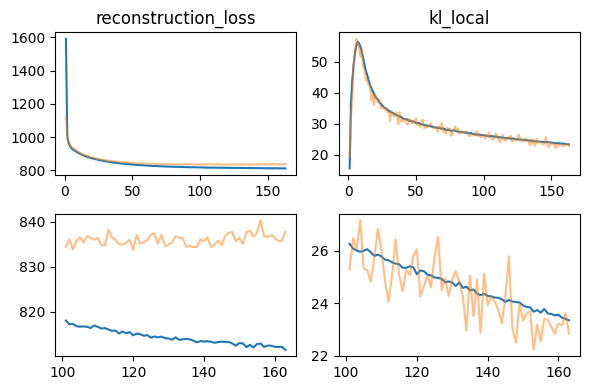

In [15]:
# Plot loses
# The plotting code below was specifically adapted to the above-specified model and its training
# If changing the model or training the plotting functions may need to be adapted accordingly

# Make detailed plot after N epochs
epochs_detail_plot = 100

# Losses to plot
losses = [
    "reconstruction_loss_train",
    "kl_local_train",
]
fig, axs = plt.subplots(2, len(losses), figsize=(len(losses) * 3, 4))
for ax_i, l_train in enumerate(losses):
    l_val = l_train.replace("_train", "_validation")
    l_name = l_train.replace("_train", "")
    # Change idx of epochs to start with 1
    l_val_values = model.trainer.logger.history[l_val].copy()
    l_val_values.index = l_val_values.index + 1
    l_train_values = model.trainer.logger.history[l_train].copy()
    l_train_values.index = l_train_values.index + 1
    for l_values, c, alpha, dp in [
        (l_train_values, "tab:blue", 1, epochs_detail_plot),
        (l_val_values, "tab:orange", 0.5, epochs_detail_plot),
    ]:
        axs[0, ax_i].plot(l_values.index, l_values.values.ravel(), c=c, alpha=alpha)
        axs[0, ax_i].set_title(l_name)
        axs[1, ax_i].plot(l_values.index[dp:], l_values.values.ravel()[dp:], c=c, alpha=alpha)

fig.tight_layout()

In [10]:

# --- Extract scVI outputs ---
Z_scvi = model.get_latent_representation()
Xden_scvi = model.get_normalized_expression(library_size=1e4)  # posterior mean "denoised"

# --- Clustering on latent (not UMAP) ---
adata_train.obsm["X_scvi"] = Z_scvi
sc.pp.neighbors(adata_train, use_rep="X_scvi", n_neighbors=30, metric="euclidean")
sc.tl.leiden(adata_train, key_added="leiden_scvi", resolution=1.0)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 6 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


=== Test Data Results ===
Test Data Shape: (1000, 3000)
Latent Representation Shape: (1000, 10)
Denoised Expression Shape: (1000, 3000)
ARI (Test): 0.5989
NMI (Test): 0.7585
Number of true cell types (test): 29
Number of detected clusters (test): 11


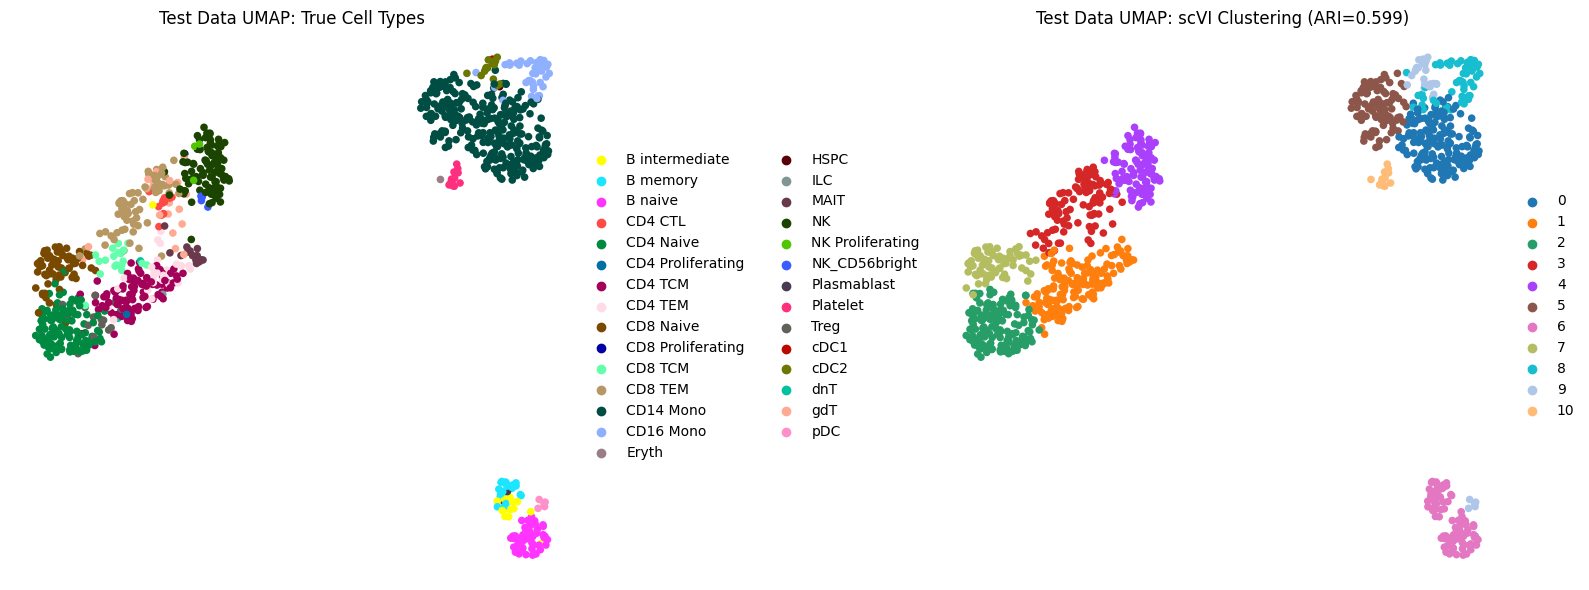


=== Train vs Test Comparison ===
Train ARI: 0.5989 | Test ARI: 0.5989
Train NMI: 0.7585 | Test NMI: 0.7585


In [11]:
# --- Apply scVI model to test data ---
# Get latent representation and denoised expression for test data
Z_scvi_test = model.get_latent_representation(adata_test)
Xden_scvi_test = model.get_normalized_expression(adata_test, library_size=1e4)

# Add test latent representation to test data
adata_test.obsm["X_scvi"] = Z_scvi_test

# Perform clustering on test data using the same parameters
sc.pp.neighbors(adata_test, use_rep="X_scvi", n_neighbors=30, metric="euclidean")
sc.tl.leiden(adata_test, key_added="leiden_scvi", resolution=1.0)

# Generate UMAP for test data
sc.tl.umap(adata_test, random_state=42)

# Calculate metrics for test data
y_true_test = adata_test.obs["cell_labels"].astype(str).values
y_pred_test = adata_test.obs["leiden_scvi"].astype(str).values
ari_scvi_test = adjusted_rand_score(y_true_test, y_pred_test)
nmi_scvi_test = normalized_mutual_info_score(y_true_test, y_pred_test)

# Display results
print("=== Test Data Results ===")
print(f"Test Data Shape: {adata_test.shape}")
print(f"Latent Representation Shape: {Z_scvi_test.shape}")
print(f"Denoised Expression Shape: {Xden_scvi_test.shape}")
print(f"ARI (Test): {ari_scvi_test:.4f}")
print(f"NMI (Test): {nmi_scvi_test:.4f}")
print(f"Number of true cell types (test): {len(np.unique(y_true_test))}")
print(f"Number of detected clusters (test): {len(np.unique(y_pred_test))}")

# Create visualization for test data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: UMAP colored by true cell types
sc.pl.umap(adata_test, color="cell_labels", 
          title="Test Data UMAP: True Cell Types", 
          ax=axes[0], show=False, frameon=False)

# Plot 2: UMAP colored by scVI clustering results  
sc.pl.umap(adata_test, color="leiden_scvi",
          title=f"Test Data UMAP: scVI Clustering (ARI={ari_scvi_test:.3f})",
          ax=axes[1], show=False, frameon=False)

plt.tight_layout()
plt.show()

# Compare train vs test performance
print(f"\n=== Train vs Test Comparison ===")
print(f"Train ARI: {ari_scvi_test:.4f} | Test ARI: {ari_scvi_test:.4f}")
print(f"Train NMI: {nmi_scvi_test:.4f} | Test NMI: {nmi_scvi_test:.4f}")

In [12]:
# --- Save latent embeddings in denoising.pt format for R script analysis ---
import torch
import pandas as pd
import os
import numpy as np

latent_dim = Z_scvi_test.shape[1]
embeddings = Z_scvi_test

# Helper to robustly convert arrays/DataFrames/Series to torch tensors
def to_torch_tensor(x, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(dtype)
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x).to(dtype)
    if isinstance(x, pd.DataFrame):
        return torch.from_numpy(x.to_numpy()).to(dtype)
    if isinstance(x, pd.Series):
        return torch.from_numpy(x.to_numpy()).to(dtype)
    # Fallback (may be a list)
    return torch.tensor(x, dtype=dtype)

# Create folder based on dimensionality FIRST, and save everything inside it
folder_name = f"scvi_results_{latent_dim}d"
os.makedirs(folder_name, exist_ok=True)

embeddings_path = os.path.join(folder_name, "denoised_embeddings.csv")
labels_path = os.path.join(folder_name, "cleaned_cell_labels_meta_tea_seq.csv")
pt_path = os.path.join(folder_name, "denoising_results.pt")

print(f"Saving scVI latent embeddings to folder: {folder_name}")
print(f"Original latent dimensions: {Z_scvi_test.shape[1]}")
print(f"Saving {latent_dim} dimensions for R script")
print(f"Test data shape: {embeddings.shape}")

# Create embeddings DataFrame (R script expects this format)
embeddings_df = pd.DataFrame(embeddings)
embeddings_df.to_csv(embeddings_path, index=True)
print(f"✓ Saved {embeddings_path}: {embeddings_df.shape}")

# Create labels DataFrame (R script expects column named 'x')
labels_df = pd.DataFrame({'x': y_true_test})
labels_df.to_csv(labels_path, index=False)
print(f"✓ Saved {labels_path}: {labels_df.shape}")

# Build categorical codes and label encoder (number -> name)
cat_labels = pd.Categorical(y_true_test)
label_codes = cat_labels.codes  # integer codes per cell
label_encoder = {str(cat): int(i) for i, cat in enumerate(cat_labels.categories)}

# Safe tensor conversions (avoid ValueError on DataFrame objects)
x_denoised_tensor = to_torch_tensor(embeddings)
x_true_tensor = to_torch_tensor(embeddings)
Xden_scvi_test_tensor = to_torch_tensor(Xden_scvi_test) if 'Xden_scvi_test' in locals() else None
Z_scvi_test_tensor = to_torch_tensor(Z_scvi_test)
label_codes_tensor = to_torch_tensor(label_codes, dtype=torch.long)

# Also save as PyTorch tensor format (similar to mixed diffusion pipeline)
results_dict = {
    'x_denoised': x_denoised_tensor,
    'x_denoised_labels': label_codes_tensor,
    'x_true': x_true_tensor,
    'data_config': {'label_encoder': label_encoder},
}

torch.save(results_dict, pt_path)
print(f"✓ Saved {pt_path} with scVI latent embeddings")

# Print summary for R script usage
print(f"\n=== Files ready for R script analysis ===")
print(f"  📄 {embeddings_path}: {embeddings.shape[0]} cells × {embeddings.shape[1]} latent dimensions")
print(f"  📄 {labels_path}: {len(y_true_test)} cell labels")
print(f"  📄 {pt_path}: PyTorch format with full results")
print(f"  🔐 Label encoder entries: {len(label_encoder)}")
print(f"\nSample label encoder mapping (first 10):")
for k in list(label_encoder.keys())[:10]:
    print(f"  {k} -> {label_encoder[k]}")

print(f"\nUnique cell types in test data: {sorted(np.unique(y_true_test))}")
print(f"Cell type distribution:")
for cell_type, count in pd.Series(y_true_test).value_counts().sort_index().items():
    print(f"  {cell_type}: {count} cells")

print(f"\n▶️  Run R script: Rscript scripts/clustering_metrics_with_.R {folder_name}")

Saving scVI latent embeddings to folder: scvi_results_10d
Original latent dimensions: 10
Saving 10 dimensions for R script
Test data shape: (1000, 10)
✓ Saved scvi_results_10d/denoised_embeddings.csv: (1000, 10)
✓ Saved scvi_results_10d/cleaned_cell_labels_meta_tea_seq.csv: (1000, 1)
✓ Saved scvi_results_10d/denoising_results.pt with scVI latent embeddings

=== Files ready for R script analysis ===
  📄 scvi_results_10d/denoised_embeddings.csv: 1000 cells × 10 latent dimensions
  📄 scvi_results_10d/cleaned_cell_labels_meta_tea_seq.csv: 1000 cell labels
  📄 scvi_results_10d/denoising_results.pt: PyTorch format with full results
  🔐 Label encoder entries: 29

Sample label encoder mapping (first 10):
  B intermediate -> 0
  B memory -> 1
  B naive -> 2
  CD14 Mono -> 3
  CD16 Mono -> 4
  CD4 CTL -> 5
  CD4 Naive -> 6
  CD4 Proliferating -> 7
  CD4 TCM -> 8
  CD4 TEM -> 9

Unique cell types in test data: ['B intermediate', 'B memory', 'B naive', 'CD14 Mono', 'CD16 Mono', 'CD4 CTL', 'CD4 Nai